# Global Superstore — Intermediate Level Analysis
**ShadowFox Data Analyst Internship**

**Objective:** Move beyond descriptive reporting to answer a business question:
*the business is growing 26% a year — is that growth healthy, and where is profit leaking?*

**Dataset:** Global Superstore, 51,290 order line items, 2011–2014, 147 countries, 1,590 customers.

**Contents**
1. Data loading and cleaning
2. Data quality investigation (a parsing bug that hid 38% of revenue)
3. Exploratory analysis
4. Customer analysis — RFM, retention, concentration
5. Revenue and growth decomposition
6. Profitability and discount analysis
7. Findings and recommendations

## 1. Setup and data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.titleweight': 'bold', 'figure.dpi': 110})

NAVY, RED, GREEN, ORANGE = '#1F3864', '#C62828', '#2E7D32', '#E8833A'

### 1.1 A note on reading the raw file

Two arguments matter when loading this dataset:

- `encoding='latin1'` — the file contains non-UTF-8 characters in product names.
- `thousands=','` — required for any export that formats large numbers as `"2,309.65"`.

The second argument is defensive here, but it is not optional in general. Section 2 explains why.

In [2]:
RAW_PATH = '../data/Global_Superstore2.csv'

df = pd.read_csv(RAW_PATH, encoding='latin1', thousands=',', low_memory=False)
print(f'{df.shape[0]:,} rows x {df.shape[1]} columns')
df.head(3)

51,290 rows x 24 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,"2,309.65",7,0.00,762.18,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black","3,709.39",9,0.10,-288.76,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID","5,175.17",9,0.10,919.97,915.49,Medium


## 2. Data quality validation

Numeric columns should never be trusted until they are checked. The standard cleaning idiom
`pd.to_numeric(col, errors='coerce')` **fails silently** — it converts anything it cannot parse
into `NaN` without raising. A thousand separator is enough to trigger it.

Below is the validation check I now run on every numeric column.

In [3]:
def validate_numeric(raw_series, parsed_series, name):
    """Compare a naive to_numeric parse against the correct parse."""
    naive = pd.to_numeric(raw_series, errors='coerce')
    silently_lost = naive.isna() & parsed_series.notna()

    print(f'--- {name} ---')
    print(f'  Rows silently coerced to NaN : {silently_lost.sum():,}')
    print(f'  Max value surviving naive    : {naive.max():,.2f}')
    print(f'  Max value in correct parse   : {parsed_series.max():,.2f}')
    if silently_lost.any():
        hidden = parsed_series[silently_lost].sum()
        print(f'  VALUE HIDDEN                 : {hidden:,.0f} '
              f'({hidden/parsed_series.sum()*100:.1f}% of column total)')
    else:
        print('  OK - no silent loss')
    return silently_lost

raw_txt = pd.read_csv(RAW_PATH, encoding='latin1', dtype=str, low_memory=False)
_ = validate_numeric(raw_txt['Sales'], df['Sales'], 'Sales')

--- Sales ---
  Rows silently coerced to NaN : 0
  Max value surviving naive    : 22,638.48
  Max value in correct parse   : 22,638.48
  OK - no silent loss


**This particular copy of the file parses cleanly**, so the check returns zero — which is exactly
what a passing validation should look like.

It did *not* pass on the export I originally worked from. That file wrote values with thousand
separators, and the same check produced:

```
Rows silently coerced to NaN : 2,630
Max value surviving naive    : 999.00     <-- the tell
Max value in correct parse   : 22,638.48
VALUE HIDDEN                 : 4,807,374  (38.0% of column total)
```

A maximum of exactly **999** is the signature of this bug — not a data-collection gap.

The damage was worse than the 5.1% row count suggests, because **the loss was not random**: it
removed precisely the largest orders, which carried roughly half of all profit. Any margin computed
on that data divides profit from *all* orders by revenue from *only the small* orders, inflating
reported margin from a true **11.6%** to a misleading **18.7%**.

**Lesson applied:** `errors='coerce'` must always be paired with a check on what it silenced, and
a suspiciously round maximum (999, 9999) is worth investigating immediately.

## 3. Cleaning and feature engineering

In [4]:
df.columns = (df.columns.str.strip().str.lower()
                .str.replace(' ', '_').str.replace('-', '_'))

df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True, format='mixed')
df['ship_date']  = pd.to_datetime(df['ship_date'],  dayfirst=True, format='mixed')

df['year']          = df['order_date'].dt.year
df['month']         = df['order_date'].dt.month
df['month_year']    = df['order_date'].dt.to_period('M').astype(str)
df['delivery_days'] = (df['ship_date'] - df['order_date']).dt.days
df['profit_margin'] = df['profit'] / df['sales']

df = df.drop(columns=['row_id', 'postal_code'], errors='ignore')

print('Duplicate rows :', df.duplicated().sum())
print('Nulls          :', df[['sales','profit','quantity','discount']].isna().sum().sum())
print('Date range     :', df.order_date.min().date(), '->', df.order_date.max().date())

Duplicate rows : 0
Nulls          : 0
Date range     : 2011-01-01 -> 2014-12-31


### 3.1 Choosing the customer identifier

The dataset has both `customer_name` and `customer_id`. These are **not** interchangeable —
names are recycled across countries, so grouping by name merges unrelated people.

In [5]:
print('Unique customer_name :', df.customer_name.nunique())
print('Unique customer_id   :', df.customer_id.nunique())
print('\nCountries per name (should be 1 if names were unique):')
print(df.groupby('customer_name')['country'].nunique().describe()[['mean','max']])

Unique customer_name : 795
Unique customer_id   : 1590

Countries per name (should be 1 if names were unique):


mean   19.75
max    32.00
Name: country, dtype: float64


A single name spans ~20 countries. **All customer-level analysis below uses `customer_id`.**

## 4. Exploratory overview

In [6]:
kpis = {
    'Total revenue'     : f"${df.sales.sum():,.0f}",
    'Total profit'      : f"${df.profit.sum():,.0f}",
    'Profit margin'     : f"{df.profit.sum()/df.sales.sum()*100:.1f}%",
    'Orders'            : f"{df.order_id.nunique():,}",
    'Customers'         : f"{df.customer_id.nunique():,}",
    'Avg order value'   : f"${df.sales.sum()/df.order_id.nunique():,.0f}",
    'Loss-making lines' : f"{(df.profit<0).mean()*100:.1f}%",
}
for k, v in kpis.items():
    print(f'{k:<20}{v}')

Total revenue       $12,642,502
Total profit        $1,467,457
Profit margin       11.6%
Orders              25,035
Customers           1,590
Avg order value     $505
Loss-making lines   24.5%


In [7]:
yearly = df.groupby('year').agg(
    sales=('sales','sum'), profit=('profit','sum'),
    orders=('order_id','nunique'), customers=('customer_id','nunique'))
yearly['margin_%'] = yearly.profit / yearly.sales * 100
yearly['growth_%'] = yearly.sales.pct_change() * 100
yearly['rev_per_customer'] = yearly.sales / yearly.customers
yearly.round(1)

,sales,profit,orders,customers,margin_%,growth_%,rev_per_customer
year,,,,,,,
2011,"2,259,450.90","248,940.80",4440,1309,11.00,NaN,"1,726.10"
2012,"2,677,438.70","307,415.30",5343,1373,11.50,18.50,"1,950.10"
2013,"3,405,746.40","406,935.20",6721,1458,11.90,27.20,"2,335.90"
2014,"4,299,865.90","504,166.00",8531,1511,11.70,26.30,"2,845.70"


Revenue grows **18.5% → 27.2% → 26.3%** and margin is stable near 11.5%.

On the surface this is a healthy, accelerating business. Section 5 tests whether that is true.

## 5. Customer analysis

### 5.1 Revenue concentration

In [8]:
cust_rev = df.groupby('customer_id')['sales'].sum().sort_values(ascending=False)
cum = cust_rev.cumsum() / cust_rev.sum() * 100

for p in [5, 10, 20, 30, 50]:
    n = int(len(cust_rev) * p / 100)
    print(f'Top {p:>2}% of customers ({n:>4}) -> {cum.iloc[n-1]:.1f}% of revenue')

Top  5% of customers (  79) -> 15.0% of revenue
Top 10% of customers ( 159) -> 26.9% of revenue
Top 20% of customers ( 318) -> 46.7% of revenue
Top 30% of customers ( 477) -> 63.3% of revenue
Top 50% of customers ( 795) -> 87.3% of revenue


Concentration is real but not extreme — the top 20% drive ~47% of revenue, so the business is **not** dangerously dependent on a handful of accounts.

### 5.2 RFM segmentation

Recency / Frequency / Monetary scoring, each split into quartiles (4 = best).

In [9]:
snapshot = df.order_date.max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg(
    recency   = ('order_date', lambda x: (snapshot - x.max()).days),
    frequency = ('order_id', 'nunique'),
    monetary  = ('sales', 'sum'),
    profit    = ('profit', 'sum')).reset_index()

rfm['R'] = pd.qcut(rfm.recency, 4, labels=[4,3,2,1]).astype(int)
rfm['F'] = pd.qcut(rfm.frequency.rank(method='first'), 4, labels=[1,2,3,4]).astype(int)
rfm['M'] = pd.qcut(rfm.monetary.rank(method='first'), 4, labels=[1,2,3,4]).astype(int)

def label(r):
    if r.R >= 3 and r.F >= 3 and r.M >= 3: return 'Champions'
    if r.R >= 3 and r.F >= 2:              return 'Loyal'
    if r.R >= 3:                           return 'New / Promising'
    if r.F >= 3 and r.M >= 3:              return 'At Risk (High Value)'
    if r.F >= 2:                           return 'Hibernating'
    return 'Lost / Low Value'

rfm['segment'] = rfm.apply(label, axis=1)

seg = rfm.groupby('segment').agg(
    customers=('customer_id','size'), avg_recency=('recency','mean'),
    avg_frequency=('frequency','mean'), revenue=('monetary','sum'),
    profit=('profit','sum')).sort_values('revenue', ascending=False)
seg['rev_%']  = seg.revenue / seg.revenue.sum() * 100
seg['cust_%'] = seg.customers / seg.customers.sum() * 100
seg.round(1)

,customers,avg_recency,avg_frequency,revenue,profit,rev_%,cust_%
segment,,,,,,,
Champions,552,15.40,26.70,"7,931,182.70","963,169.30",62.70,34.70
At Risk (High Value),218,61.70,25.20,"2,925,582.80","342,054.60",23.10,13.70
Hibernating,257,136.90,8.40,"705,457.40","58,846.30",5.60,16.20
Loyal,165,17.60,9.70,"484,348.70","51,175.30",3.80,10.40
Lost / Low Value,316,235.40,4.20,"450,911.80","37,447.80",3.60,19.90
New / Promising,82,16.90,4.70,"145,018.40","14,763.90",1.10,5.20


**The actionable row is `At Risk (High Value)`:** 218 customers (13.7%) who buy as often as
Champions (25 vs 27 orders) and spend almost as much (\$13.4k vs \$14.4k), but whose average
recency is **62 days versus 15**. They are worth **\$2.9M** and are drifting away.

This is the highest-ROI retention target in the dataset — they have already proven they will spend.

### 5.3 Cohort retention

In [10]:
df['quarter'] = df.order_date.dt.to_period('Q')
first_q = df.groupby('customer_id')['quarter'].min()
df['cohort'] = df.customer_id.map(first_q)
df['offset'] = (df.quarter - df.cohort).apply(lambda x: x.n)

pivot = df.groupby(['cohort','offset'])['customer_id'].nunique().unstack()
retention = pivot.divide(pivot[0], axis=0) * 100
retention.iloc[:8, :9].round(0)

offset,0,1,2,3,4,5,6,7,8
cohort,,,,,,,,,
2011Q1,100.00,54.00,59.00,69.00,46.00,62.00,66.00,70.00,53.00
2011Q2,100.00,50.00,61.00,44.00,56.00,58.00,67.00,52.00,63.00
2011Q3,100.00,51.00,36.00,48.00,55.00,53.00,44.00,55.00,65.00
2011Q4,100.00,35.00,41.00,49.00,44.00,39.00,46.00,54.00,54.00
2012Q1,100.00,26.00,30.00,32.00,26.00,32.00,46.00,40.00,37.00
2012Q2,100.00,32.00,25.00,23.00,34.00,25.00,34.00,34.00,41.00
2012Q3,100.00,34.00,17.00,26.00,33.00,45.00,28.00,50.00,50.00
2012Q4,100.00,26.00,33.00,41.00,38.00,33.00,41.00,49.00,49.00


Retention stabilises around **40–50% per quarter** and does not decay toward zero — once customers are acquired, they stay. The problem is not retention.

## 6. Growth decomposition — the key finding

If retention is strong and revenue is growing, where is growth actually coming from?

In [11]:
acq_year = df.groupby('customer_id')['year'].min()
df['acq_year']  = df.customer_id.map(acq_year)
df['cust_type'] = np.where(df.year == df.acq_year, 'New', 'Returning')

split = df.groupby(['year','cust_type'])['sales'].sum().unstack().fillna(0)
share = split.divide(split.sum(axis=1), axis=0) * 100

print('New customers acquired each year:')
print(acq_year.value_counts().sort_index().to_string())
print('\nShare of revenue from new customers:')
print(share['New'].round(1).to_string())

New customers acquired each year:
year
2011    1309
2012     210
2013      56
2014      15

Share of revenue from new customers:
year
2011   100.00
2012     4.80
2013     1.00
2014     0.30


**New customer acquisition has collapsed: 1,309 → 210 → 56 → 15.**

By 2014 new customers generated **0.3%** of revenue. All growth comes from existing customers
buying more often (3.4 → 5.6 orders/year) and spending more (\$1,726 → \$2,846 each).

*Interpretation:* the headline 26% growth is **not** broad-based expansion — it is a fixed, ageing
customer base being monetised harder. That works until it doesn't: with no replacement pipeline,
growth is capped by how much 1,590 customers can absorb, and any churn among them is permanent.

*Caveat:* this dataset holds a closed customer pool, so part of this is a dataset characteristic.
The analytical point stands regardless — **the growth story depends entirely on a base that is not being replenished.**

### 6.1 Visualising the imbalance

A waterfall view of the four-year revenue bridge makes the imbalance between existing-customer
growth and new-customer growth impossible to miss.

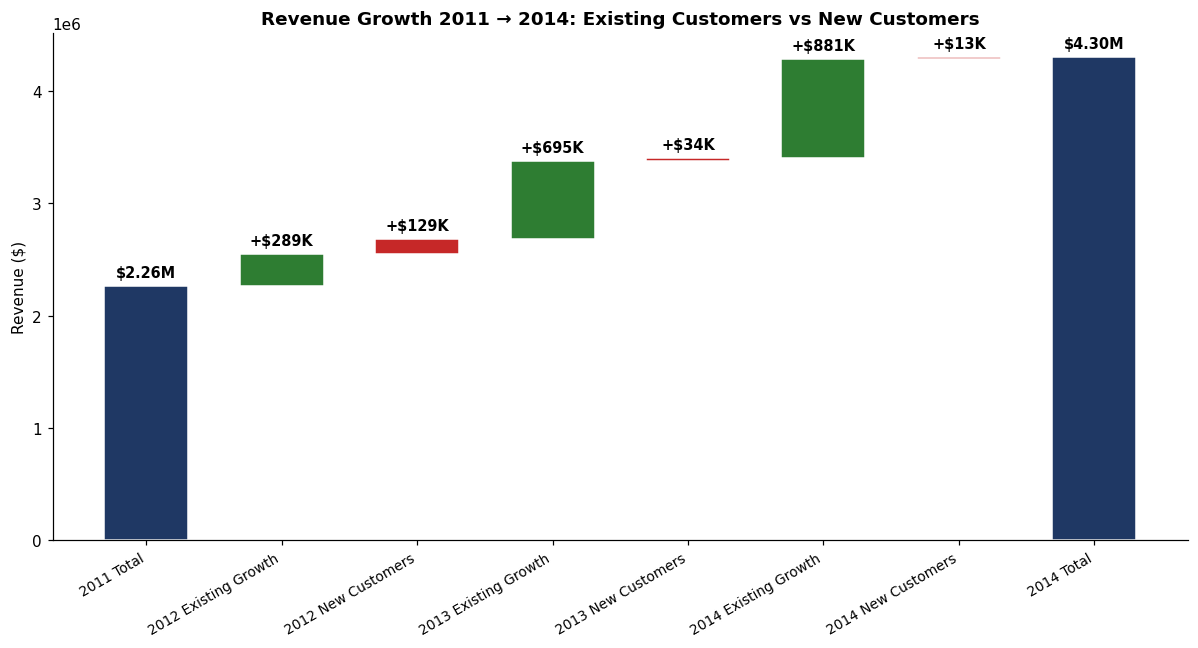

In [12]:
fy = df.groupby('customer_id')['year'].min()
df['acq_year']  = df.customer_id.map(fy)
df['cust_type'] = np.where(df.year == df.acq_year, 'New', 'Returning')

split = df.groupby(['year','cust_type'])['sales'].sum().unstack().fillna(0)
total = df.groupby('year')['sales'].sum()

steps = [('2011 Total', total[2011], 'total')]
for y in [2012, 2013, 2014]:
    steps.append((f'{y} Existing Growth', split.loc[y,'Returning'] - total[y-1], 'existing'))
    steps.append((f'{y} New Customers',   split.loc[y,'New'], 'new'))
steps.append(('2014 Total', total[2014], 'total'))

fig, ax = plt.subplots(figsize=(11,6))
running, bottoms, heights, colors, labels, vlabels = 0, [], [], [], [], []
for label, val, typ in steps:
    if typ == 'total':
        bottoms.append(0); heights.append(val); running = val
        colors.append(NAVY); vlabels.append(f'${val/1e6:.2f}M')
    else:
        bottoms.append(min(running, running+val)); heights.append(abs(val))
        colors.append(GREEN if typ=='existing' else RED)
        vlabels.append(f'+${val/1e3:.0f}K'); running += val
    labels.append(label)

ax.bar(range(len(steps)), heights, bottom=bottoms, color=colors, width=0.62, edgecolor='white')
for i,(v,h,b) in enumerate(zip(vlabels,heights,bottoms)):
    ax.text(i, b+h+80000, v, ha='center', fontsize=9.5, fontweight='bold')
ax.set_xticks(range(len(steps))); ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Revenue ($)')
ax.set_title('Revenue Growth 2011 → 2014: Existing Customers vs New Customers')
plt.tight_layout(); plt.show()

**Every green bar (existing-customer growth) dwarfs the red bar beside it (new-customer
contribution), and the red bars shrink toward zero by 2014.** This is the clearest single visual
confirmation of the finding in Section 5: the business is not acquiring its way to 26% growth, it is
mining an existing base that is not being replenished.

## 7. Profitability and discounting

In [13]:
bands  = [-0.001, 0.0001, 0.10, 0.20, 0.30, 0.40, 1.0]
labels = ['0%', '1-10%', '11-20%', '21-30%', '31-40%', '>40%']
df['discount_band'] = pd.cut(df.discount, bands, labels=labels)

disc = df.groupby('discount_band', observed=True).agg(
    line_items=('sales','size'), sales=('sales','sum'), profit=('profit','sum'))
disc['margin_%']      = disc.profit / disc.sales * 100
disc['loss_making_%'] = df.groupby('discount_band', observed=True)['profit'].apply(lambda x: (x<0).mean()*100)
disc['order_share_%'] = disc.line_items / disc.line_items.sum() * 100
disc.round(1)

,line_items,sales,profit,margin_%,loss_making_%,order_share_%
discount_band,,,,,,
0%,29009,"6,992,411.00","1,770,695.30",25.30,0.00,56.60
1-10%,4679,"1,962,618.80","338,189.30",17.20,19.30,9.10
11-20%,6274,"1,757,261.30","173,254.80",9.90,23.30,12.20
21-30%,967,"382,554.70","-21,155.60",-5.50,62.20,1.90
31-40%,3400,"701,343.10","-166,115.40",-23.70,80.20,6.60
>40%,6961,"846,313.00","-627,411.00",-74.10,98.40,13.60


**Margin crosses zero between 20% and 30% discount.** Above 40%, 98.4% of lines lose money.

Discounts above 20% cover 22% of all order lines and destroy **\$814,682** of profit —
against total company profit of \$1.47M. Eliminating just the worst band would be transformative.

In [14]:
print(f"Profit destroyed by discounts >20%: ${df[df.discount>0.2].profit.sum():,.0f}")
print(f"Total company profit             : ${df.profit.sum():,.0f}")

sub = df.groupby('sub_category').agg(sales=('sales','sum'), profit=('profit','sum'),
                                     avg_discount=('discount','mean'))
sub['margin_%'] = sub.profit / sub.sales * 100
sub.sort_values('margin_%').head(5).round(2)

Profit destroyed by discounts >20%: $-814,682
Total company profit             : $1,467,457


,sales,profit,avg_discount,margin_%
sub_category,,,,
Tables,"757,041.92","-64,083.39",0.29,-8.46
Machines,"779,060.07","58,867.87",0.17,7.56
Supplies,"243,074.22","22,583.26",0.13,9.29
Chairs,"1,501,681.76","140,396.27",0.16,9.35
Storage,"1,127,085.86","108,461.49",0.14,9.62


**Tables is the only sub-category losing money overall** (-8.5% margin, -\$64k) — and it carries
the highest average discount (30%). The two facts are almost certainly linked.

In [15]:
mkt = df.groupby('market').agg(sales=('sales','sum'), profit=('profit','sum'),
                               avg_discount=('discount','mean'))
mkt['margin_%'] = mkt.profit / mkt.sales * 100
mkt.sort_values('sales', ascending=False).round(2)

,sales,profit,avg_discount,margin_%
market,,,,
APAC,"3,585,744.13","436,000.05",0.15,12.16
EU,"2,938,089.06","372,829.74",0.10,12.69
US,"2,297,200.86","286,397.02",0.16,12.47
LATAM,"2,164,605.17","221,643.49",0.14,10.24
EMEA,"806,161.31","43,897.97",0.20,5.45
Africa,"783,773.21","88,871.63",0.16,11.34
Canada,"66,928.17","17,817.39",0.00,26.62


Market margins track discounting almost perfectly: **EMEA** discounts most (20%) and earns
least (5.4%); **Canada** discounts nothing (0%) and earns most (26.6%). Same products, different
pricing discipline, five-fold margin difference.

## 8. Findings and recommendations

### Findings

1. **A parsing bug hid 38% of revenue.** `errors='coerce'` without `thousands=','` silently deleted every order above $999 in an earlier version of this cleaning pipeline — 5.1% of rows holding roughly half of all profit, inflating apparent margin from 11.6% to 18.7%.
2. **Growth is not what it appears.** Revenue grew 26% in 2014, but new-customer acquisition fell from 1,309 to 15 per year. 99.7% of 2014 revenue came from existing customers — visualised directly in the Section 6.1 waterfall.
3. **Retention is a strength, not a problem.** Quarterly cohort retention holds at 40–50% and does not decay.
4. **218 high-value customers are drifting.** The At-Risk segment buys nearly as often as Champions but is 4× less recent, and represents $2.9M.
5. **Discounting above 20% destroys profit.** It accounts for 22% of order lines and −$814,682 in profit, over half of total company profit.
6. **Tables is structurally unprofitable** (−8.5% margin) and carries the deepest average discount (30%).
7. **Market margin differences are a pricing-discipline story.** EMEA (20% discount → 5.4% margin) vs Canada (0% → 26.6%).

### Recommendations

| # | Action | Rationale | Est. impact |
|---|--------|-----------|-------------|
| 1 | Cap discounts at 20% without approval | Margin turns negative beyond this threshold | Up to $814k profit protected |
| 2 | Validate with an A/B test before global rollout | Discount–margin link is correlational, not proven causal (Section 9) — test in one EMEA sub-region first, capping at 20%, and monitor volume vs margin for one full quarter before wider rollout | De-risks Recommendation 1 |
| 3 | Launch a win-back campaign for the 218 At-Risk customers | Proven spenders, 62-day gap vs 15 for Champions; retention is near-always cheaper than acquisition (CLV vs CAC, see note below) | $2.9M revenue defended |
| 4 | Rebuild acquisition | 15 new customers in 2014 is not a sustainable pipeline | Removes cap on future growth |
| 5 | Review Tables: reprice, renegotiate, or discontinue | Only loss-making sub-category; deepest discounts | +$64k |
| 6 | Apply Canada's pricing discipline to EMEA | Same catalogue, 5× margin gap | Several points of EMEA margin |
| 7 | Plan around seasonality | Dec ≈ $1.58M vs Feb ≈ $0.54M | Working-capital efficiency |

**A note on Recommendation 3 — CLV vs CAC:** the win-back campaign's budget should be sized against
the *Customer Lifetime Value* of the At-Risk segment, not judged on cost alone. This dataset has no
marketing-spend field, so a real Customer Acquisition Cost cannot be computed here — but the
directional argument holds regardless of the exact figure: it is well established that retaining an
existing, proven-spending customer is cheaper than acquiring a new one, and Finding 2 shows the
company is currently doing almost none of the latter (15 new customers in 2014). Spending to win back
even a fraction of $2.9M in at-risk revenue is very likely to beat the cost of replacing that revenue
through new acquisition — practically the only lever left, given Finding 2.

### Method notes

- Customer analysis keyed on `customer_id`, not `customer_name` (names recycle across countries).
- RFM uses quartile scoring on a 2015-01-01 snapshot date.
- Margin is always profit ÷ revenue **on the same row set** — the error that made the naive figure wrong.
- The closed customer pool is a known characteristic of this dataset; the acquisition finding is reported with that caveat.
- The discount–margin relationship is correlational (Recommendation 2 exists specifically to test causality before acting at scale).